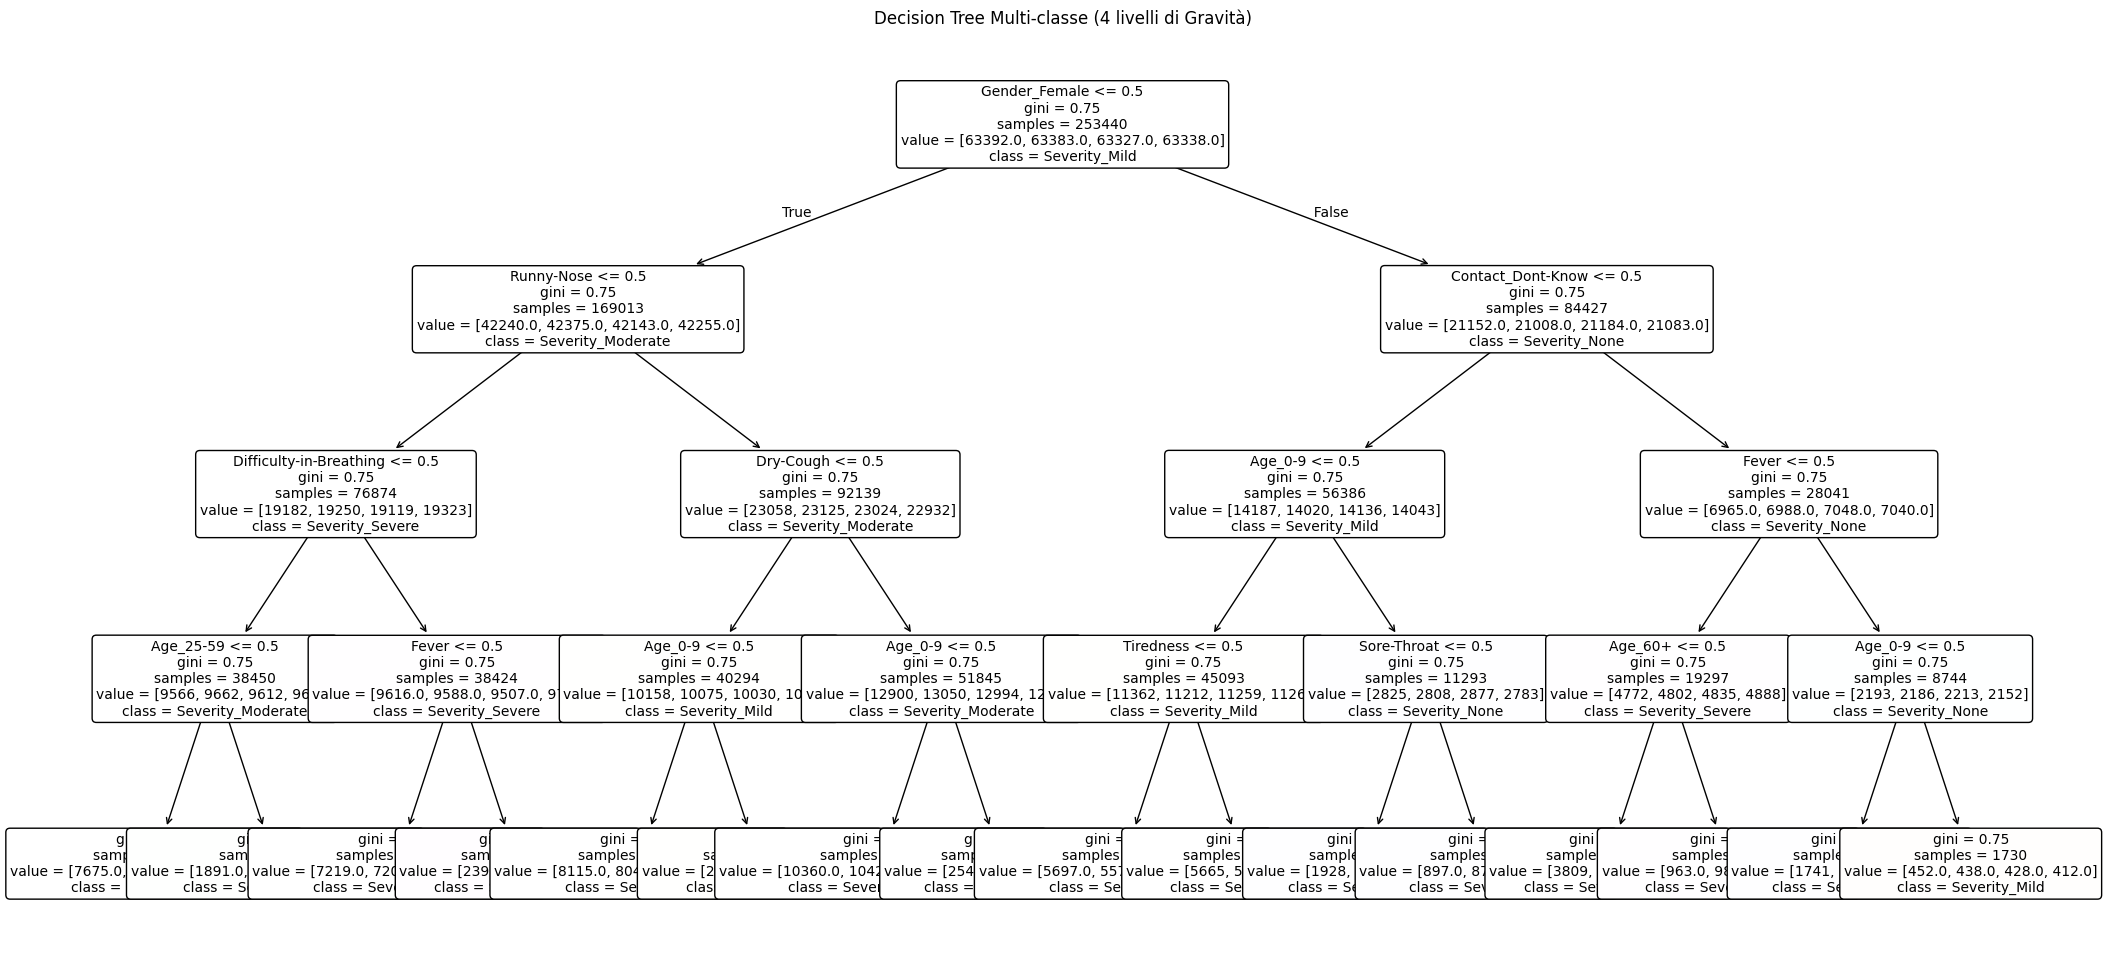

<Figure size 1000x800 with 0 Axes>

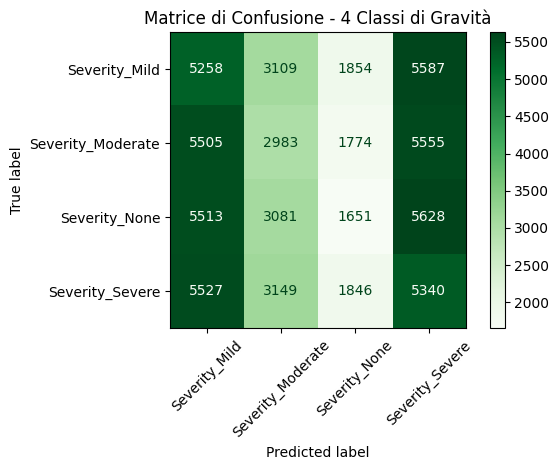

Distribuzione delle classi nel dataset:
Target_Severity
Severity_Mild        79200
Severity_Moderate    79200
Severity_Severe      79200
Severity_None        79200
Name: count, dtype: int64


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Caricamento del dataset
df = pd.read_csv('Cleaned-Data.csv')

# Trasformazione del Target: da 4 colonne a 1 singola colonna multi-classe
# Usiamo idxmax per capire quale colonna ha il valore '1' per ogni riga
data = df.drop(columns=['Severity_None', 'Severity_Mild', 'Severity_Moderate', 'Severity_Severe', 'Country'])
target = ['Severity_None', 'Severity_Mild', 'Severity_Moderate', 'Severity_Severe']
df['Target_Severity'] = df[target].idxmax(axis=1)


# Preparazione delle feature (X) e del target (y)
# Escludiamo le colonne target originali e la colonna Country
X = df.drop(columns=target + ['Country', 'Target_Severity'])
y = df['Target_Severity']

# Suddivisione dei dati (Train/Test)
# Stratifichiamo su y per mantenere il perfetto bilanciamento delle 4 classi
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=108)

# Creazione e addestramento dell'Albero Decisionale
# Impostiamo una profondità leggermente maggiore (max_depth=4) per gestire la complessità delle 4 classi
clf_multi = DecisionTreeClassifier(max_depth=4, random_state=1000)
clf_multi.fit(X_train, y_train)

# Visualizzazione dell'Albero Decisionale
plt.figure(figsize=(25, 12))
plot_tree(clf_multi,
          feature_names=X.columns.tolist(),
          class_names=clf_multi.classes_.tolist(),
          filled=True,
          rounded=True,
          fontsize=10)
plt.title("Decision Tree Multi-classe (4 livelli di Gravità)")
plt.savefig('multi_class_tree.png')
plt.show()

# Generazione della Matrice di Confusione Multi-classe
y_pred = clf_multi.predict(X_test)
cm = confusion_matrix(y_test, y_pred, labels=clf_multi.classes_)

plt.figure(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf_multi.classes_)
disp.plot(cmap=plt.cm.Greens, values_format='d')
plt.title('Matrice di Confusione - 4 Classi di Gravità')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('multi_confusion_matrix.png')
plt.show()

# Verifica del bilanciamento
print("Distribuzione delle classi nel dataset:")
print(df['Target_Severity'].value_counts())

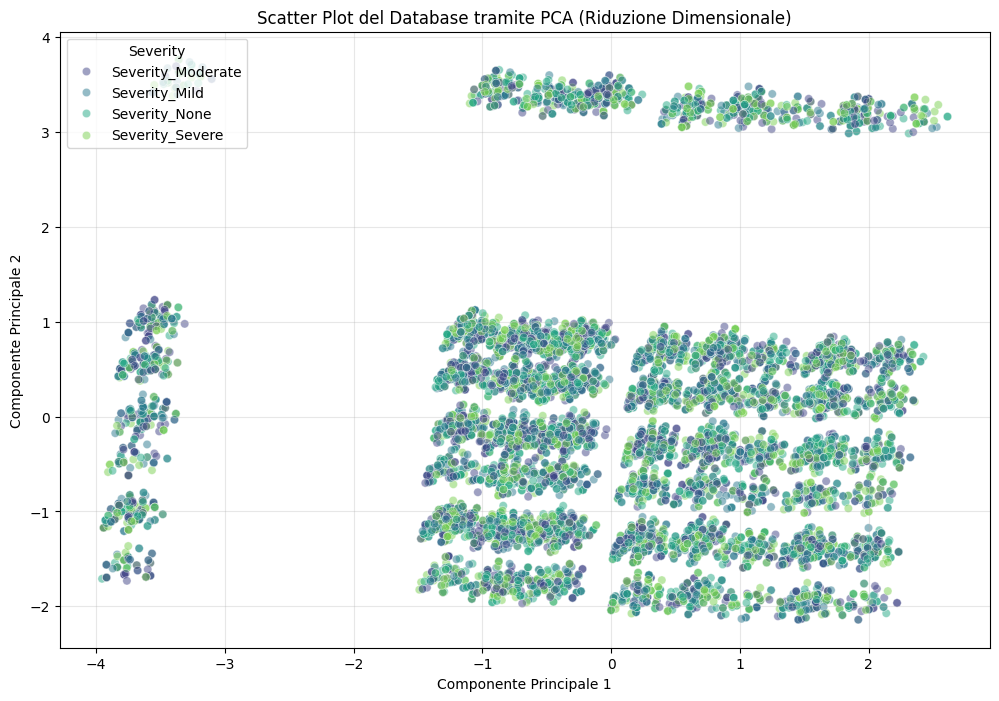

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Caricamento e preparazione (Target multi-classe)
df = pd.read_csv('Cleaned-Data.csv')
severity_cols = ['Severity_None', 'Severity_Mild', 'Severity_Moderate', 'Severity_Severe']
df['Target_Severity'] = df[severity_cols].idxmax(axis=1)

# Selezione Feature e Campionamento
# Usiamo un campione di 10.000 righe per rendere il grafico leggibile
df_sample = df.sample(n=10000, random_state=42)
X_sample = df_sample.drop(columns=severity_cols + ['Country', 'Target_Severity'])
y_sample = df_sample['Target_Severity']

# Standardizzazione e PCA
X_scaled = StandardScaler().fit_transform(X_sample)
pca = PCA(n_components=2)
pca_res = pca.fit_transform(X_scaled)

# Creazione DataFrame per lo scatter
pca_df = pd.DataFrame(data=pca_res, columns=['PCA1', 'PCA2'])
pca_df['Severity'] = y_sample.values

# Plot
plt.figure(figsize=(12, 8))
sns.scatterplot(x='PCA1', y='PCA2', hue='Severity', data=pca_df, alpha=0.5, palette='viridis')
plt.title('Scatter Plot del Database tramite PCA (Riduzione Dimensionale)')
plt.xlabel('Componente Principale 1')
plt.ylabel('Componente Principale 2')
plt.grid(True, alpha=0.3)
plt.savefig('scatter_pca_covid.png')
plt.show()

In [ ]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Caricamento dataset
df = pd.read_csv('Cleaned-Data.csv')

# Definisco i gruppi di sintomi
respiratory_cols = ['Dry-Cough', 'Difficulty-in-Breathing', 'Sore-Throat', 'Nasal-Congestion', 'Runny-Nose']
systemic_cols = ['Fever', 'Tiredness', 'Pains', 'Diarrhea']

# Creo le due nuove feature sommando i sintomi
df['Total_Respiratory'] = df[respiratory_cols].sum(axis=1) # Cambiamo l'asse
df['Total_Systemic'] = df[systemic_cols].sum(axis=1)

# Filtro: tengo solo i pazienti che hanno effettivamente dei sintomi
condition = (
    (df['None_Sympton'] == 0) &
    (df['None_Experiencing'] == 0) &
    ((df['Total_Respiratory'] > 0) | (df['Total_Systemic'] > 0))
)
df_clean = df[condition].copy()
# (Rimuovo chi ha 'None_Sympton' a 1 o somma sintomi a 0)

# Controllo veloce per vedere quante righe ho perso
print(f"Shape originale: {df.shape}")
print(f"Shape dopo filtro: {df_clean.shape}")

# Preparazione dati per KMeans
X = df_clean[['Total_Respiratory', 'Total_Systemic']]

# Standardizzo i dati (necessario per le distanze euclidee del KMeans)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Clustering su 4 gruppi
kmeans = KMeans(n_clusters=4, random_state=775, n_init=300)
df_clean['Phenotype_Cluster'] = kmeans.fit_predict(X_scaled)

# Vediamo come sono distribuiti i cluster
print("\nDistribuzione Cluster:")
print(df_clean['Phenotype_Cluster'].value_counts().sort_index())

Shape originale: (316800, 29)
Shape dopo filtro: (270000, 29)

Distribuzione Cluster:
Phenotype_Cluster
0    68400
1    70200
2    77400
3    54000
Name: count, dtype: int64


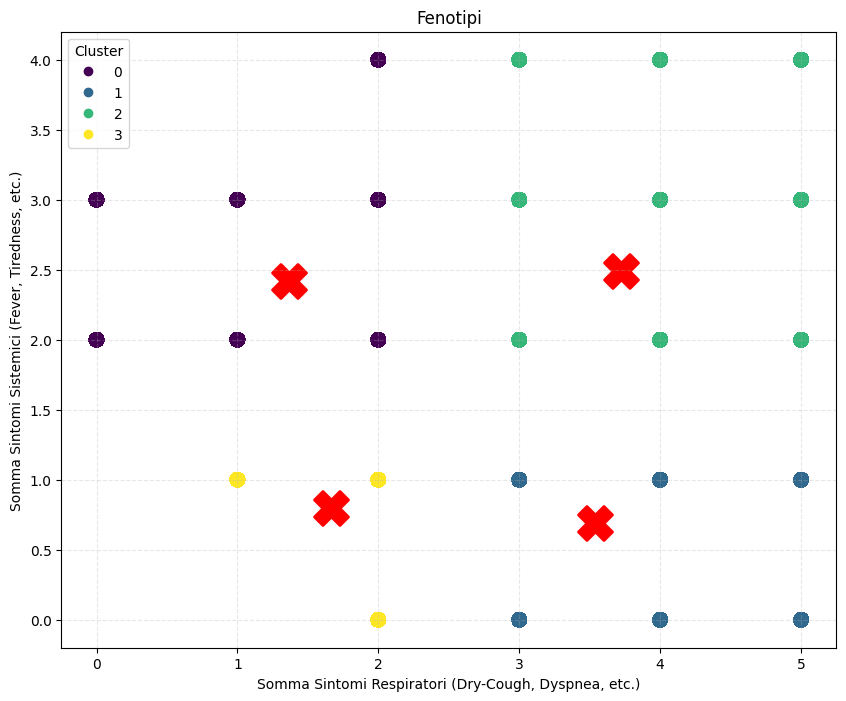

In [ ]:
import matplotlib.pyplot as plt

# Recupero i centroidi convertiti (dai numeri scalati a quelli reali)
centroids_real = scaler.inverse_transform(kmeans.cluster_centers_)

plt.figure(figsize=(10, 8))

# Plot dei Pazienti
# I dati sono numeri interi e si sovrappongono.
scatter = plt.scatter(
    df_clean['Total_Respiratory'],
    df_clean['Total_Systemic'],
    c=df_clean['Phenotype_Cluster'],
    cmap='viridis',
    s=100, # Dimensione punti
    alpha=1 # Trasparenza fondamentale per vedere la densità
)

# Plot dei Centroidi
plt.scatter(
    centroids_real[:, 0],
    centroids_real[:, 1],
    c='red',
    marker='X',
    s=600,
    linewidths=2,
    label='Centroidi'
)
plt.title('Fenotipi')
plt.xlabel('Somma Sintomi Respiratori (Dry-Cough, Dyspnea, etc.)')
plt.ylabel('Somma Sintomi Sistemici (Fever, Tiredness, etc.)')
plt.grid(True, linestyle='--', alpha=0.3)

# Legenda automatica
plt.legend(*scatter.legend_elements(), loc="upper left", title="Cluster")
plt.show()

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

# Re-defining features and training clf to make this cell runnable independently
features = [
    'Fever', 'Tiredness', 'Dry-Cough', 'Difficulty-in-Breathing',
    'Sore-Throat', 'Pains', 'Nasal-Congestion', 'Runny-Nose', 'Diarrhea'
]

# Assuming df_clean and Phenotype_Cluster are defined from previous cells (JfnqSgb3RV36)
# Based on kernel state, df_clean is defined.
X = df_clean[features]
y = df_clean['Phenotype_Cluster']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=775)
clf = DecisionTreeClassifier(max_depth=4, random_state=100)
clf.fit(X_train, y_train)


importances = pd.DataFrame({
    'Sintomo': features,
    'Importanza': clf.feature_importances_
}).sort_values(by='Importanza', ascending=False)

print(importances)

                   Sintomo  Importanza
1                Tiredness    0.259293
3  Difficulty-in-Breathing    0.256483
0                    Fever    0.147390
7               Runny-Nose    0.141918
5                    Pains    0.093833
8                 Diarrhea    0.052763
2                Dry-Cough    0.038990
6         Nasal-Congestion    0.009330
4              Sore-Throat    0.000000


<Figure size 1000x800 with 0 Axes>

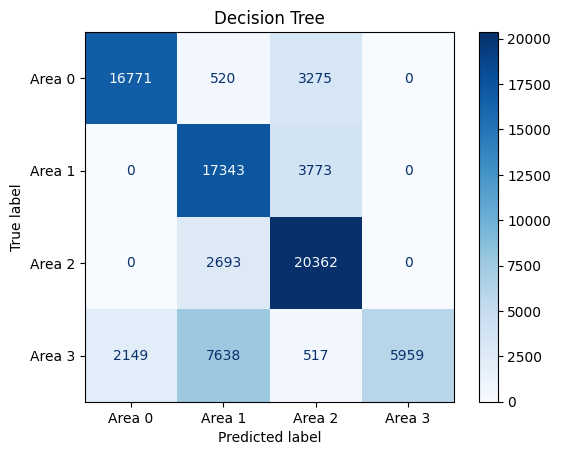

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.tree import DecisionTreeClassifier

# X = Sintomi binari (Features)
# y = Cluster del K-Means (Target)
features = [
    'Fever', 'Tiredness', 'Dry-Cough', 'Difficulty-in-Breathing',
    'Sore-Throat', 'Pains', 'Nasal-Congestion', 'Runny-Nose', 'Diarrhea'
]
X = df_clean[features]
y = df_clean['Phenotype_Cluster']

# Dividiamo i dati per testare l'albero su pazienti "mai visti"
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=775)

# Addestramento
clf = DecisionTreeClassifier(max_depth=4, random_state=100)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

# Matrice di confusione
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[f'Area {i}' for i in range(4)])
plt.figure(figsize=(10, 8))
disp.plot(cmap='Blues', values_format='d')
plt.title('Decision Tree')
plt.grid(False)
plt.show()

In [ ]:
from sklearn.metrics import classification_report

# Report Finale
print("--- Report di Classificazione DT ---\n")
print(classification_report(y_test, y_pred, target_names=[f'Area {i}' for i in range(4)]))

--- Report di Classificazione DT ---

              precision    recall  f1-score   support

      Area 0       0.89      0.82      0.85     20566
      Area 1       0.62      0.82      0.70     21116
      Area 2       0.73      0.88      0.80     23055
      Area 3       1.00      0.37      0.54     16263

    accuracy                           0.75     81000
   macro avg       0.81      0.72      0.72     81000
weighted avg       0.79      0.75      0.73     81000



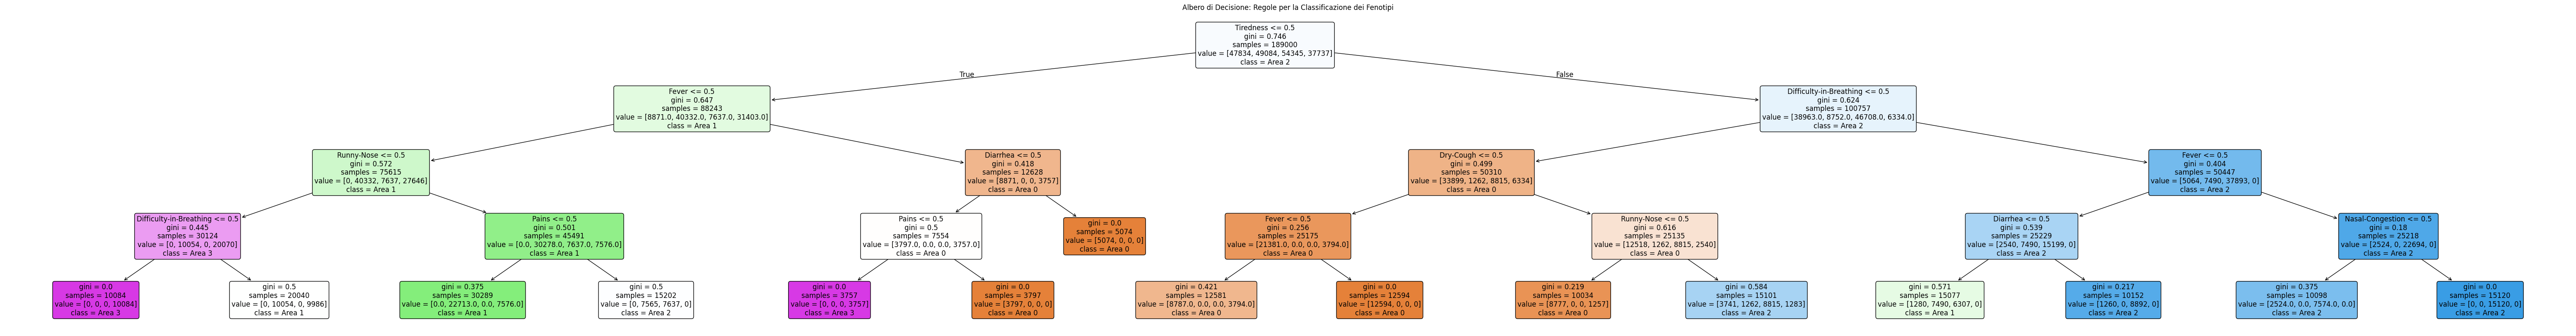

In [ ]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

# Plot albero (white box)
plt.figure(figsize=(80, 10))
plot_tree(
    clf,
    feature_names=features,
    class_names=[f'Area {i}' for i in range(4)],
    filled=True,
    rounded=True,
    fontsize=12
)
plt.title("Albero di Decisione: Regole per la Classificazione dei Fenotipi")
plt.savefig('decision_tree_fenotipi.png')
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

# Usiamo i sintomi originali come X per vedere come influenzano i cluster
# Escludiamo le colonne che abbiamo creato noi (Total_Respiratory, Total_Systemic, Phenotype_Cluster)
features_originali = respiratory_cols + systemic_cols
X_rf = df_clean[features_originali]
y_rf = df_clean['Phenotype_Cluster']

# Split in training e test set
X_train, X_test, y_train, y_test = train_test_split(X_rf, y_rf, test_size=0.3, random_state=775)

# Allenamento del modello con random_state 775
rf = RandomForestClassifier(n_estimators=6, random_state=775)
rf.fit(X_train, y_train)

# Generazione delle predizioni:
# Ogni riga di X_test attraversa tutti gli n_estimators (alberi) della foresta.
# La classe finale in y_pred è determinata dalla maggioranza dei voti espressi dai singoli alberi
y_pred = rf.predict(X_test)

# Report Finale
print("--- Report di Classificazione RF ---\n")
print(classification_report(y_test, y_pred))

--- Report di Classificazione RF ---

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     20566
           1       1.00      1.00      1.00     21116
           2       1.00      1.00      1.00     23055
           3       1.00      1.00      1.00     16263

    accuracy                           1.00     81000
   macro avg       1.00      1.00      1.00     81000
weighted avg       1.00      1.00      1.00     81000



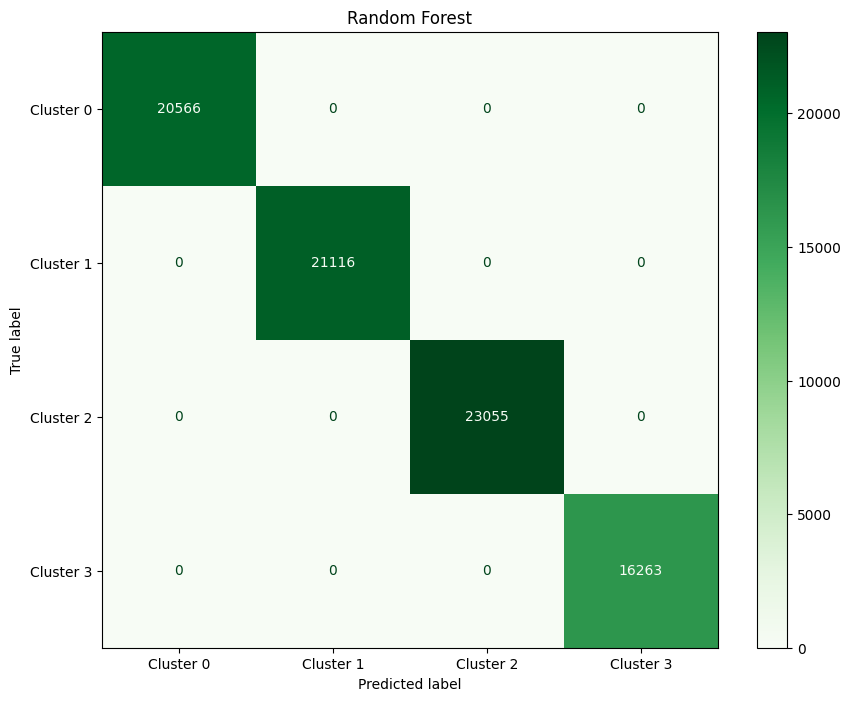

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Matrice di confusione
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[f'Cluster {i}' for i in range(4)])

plt.figure(figsize=(10, 8))
disp.plot(cmap='Greens', values_format='d', ax=plt.gca())

plt.title('Random Forest')
plt.grid(False)
plt.show()

In [ ]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

# Utilizziamo le feature create in precedenza
features_originali = respiratory_cols + systemic_cols
X = df_clean[features_originali]
y = df_clean['Phenotype_Cluster']

# Split dei dati
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=775)

# Rendiamo i dati omogenei con lo scaling
scaler_svm = StandardScaler()
X_train_scaled = scaler_svm.fit_transform(X_train)
X_test_scaled = scaler_svm.transform(X_test)

# Usiamo un kernel='linear'
svm_model = SVC(gamma='scale', random_state=775)
svm_model.fit(X_train_scaled, y_train)

# Report
y_pred_svm = svm_model.predict(X_test_scaled)

print("--- Report di Classificazione SVM ---\n")
print(classification_report(y_test, y_pred_svm))

--- Report di Classificazione SVM ---

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     20566
           1       1.00      1.00      1.00     21116
           2       1.00      1.00      1.00     23055
           3       1.00      1.00      1.00     16263

    accuracy                           1.00     81000
   macro avg       1.00      1.00      1.00     81000
weighted avg       1.00      1.00      1.00     81000



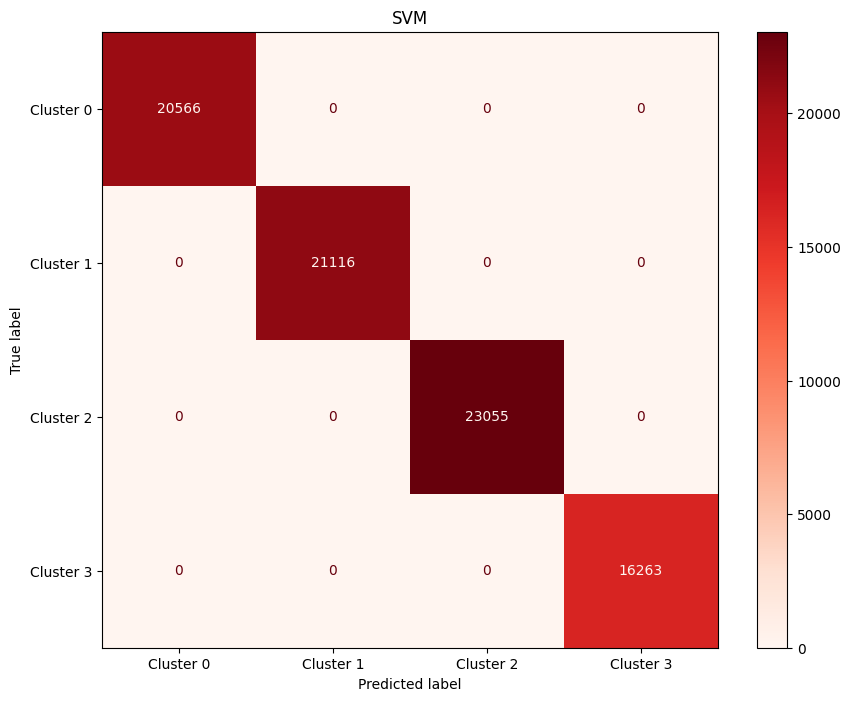

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_svm = confusion_matrix(y_test, y_pred_svm)
disp_svm = ConfusionMatrixDisplay(confusion_matrix=cm_svm, display_labels=[f'Cluster {i}' for i in range(4)])

plt.figure(figsize=(10, 8))
disp_svm.plot(cmap='Reds', values_format='d', ax=plt.gca())

plt.title('SVM')
plt.grid(False)
plt.show()